In [1]:
import json
import numpy as np
import pandas as pd
from rich import print
from matplotlib import pyplot as plt
from matplotlib import rcParams as rc

rc["font.family"] = "Times New Roman"
rc["font.size"] = 14
rc["figure.figsize"] = (6, 4)
rc["axes.grid"] = True

In [2]:
import simpeg.electromagnetics.time_domain as tdem
from simpeg.utils import plot_1d_layer_model, download, mkvc
from simpeg import (
    maps,
    data,
    data_misfit,
    regularization,
    optimization,
    inverse_problem,
    inversion,
    directives,
)
from discretize import TensorMesh
import empymod as empy

In [3]:
istart_channel:int = 1
# Load the configuration file
conf = json.load(open("../data/atem.json"))
times = np.asarray(conf['channels'])[istart_channel:] * 1e-6
n_turns = conf['n_turns']

In [4]:
area:str = "NE"
path:str = f"../data/11-024_Alberta_{area}.csv"
dheader:list = [f"zoff30[{i}]" for i in range(istart_channel,30)]
picker:list = ["Line", "bheight", "TranPeak", "x_wgs84", "y_wgs84", "flight", 'pwrline'] + dheader # power line monitor

In [5]:
raws = pd.read_csv(path)[picker]

In [6]:
xy = raws[["x_wgs84", "y_wgs84"]].to_numpy()
normalizer = (-1e-9)/ (raws["TranPeak"].values * n_turns).reshape(-1, 1)
raws[[f"zoff30[{i}]" for i in range(istart_channel, 30)]] = raws[[f"zoff30[{i}]" for i in range(istart_channel, 30)]] * normalizer

In [7]:
line_no = list(raws["Line"].unique())

In [8]:
line_no

['L10040',
 'L10050',
 'L10051',
 'L10060',
 'L10070',
 'L10071',
 'L10072',
 'L10080',
 'L10081',
 'L10090',
 'L10091',
 'L10100',
 'L10110',
 'L10120',
 'L10130',
 'L10140',
 'L10150',
 'L10151',
 'L10160',
 'L10170',
 'L10171',
 'L10180',
 'L10181',
 'L10190',
 'L10191',
 'L10192',
 'L10200',
 'L10201',
 'L10210',
 'L10211',
 'L10212',
 'L10220',
 'L10221',
 'L10222',
 'L10230',
 'L10231',
 'L10232',
 'L10240',
 'L10241',
 'L10242',
 'L10250',
 'L10251',
 'L10252',
 'L10260',
 'L10261',
 'L10270',
 'L10271',
 'L10272',
 'L10273',
 'L10280',
 'L10281',
 'L10290',
 'L10300',
 'L10310',
 'L10320',
 'L10321',
 'L10330',
 'L10340',
 'L10341',
 'L10350',
 'L10360',
 'L10361',
 'L10362',
 'L10370',
 'L10380',
 'L10390',
 'L10400',
 'L10410',
 'L10420',
 'L10430',
 'L10431',
 'L10440',
 'L10441',
 'L10450',
 'L10460',
 'L10461',
 'L10470',
 'L10471',
 'L10472',
 'L10480',
 'L10481',
 'L10490',
 'L10491',
 'L10500',
 'L10510',
 'L10511',
 'L10520',
 'L10521',
 'L10522',
 'L10530',
 'L10540',

In [9]:
istart:int = 23
iend:int = 24
index = raws["Line"] == line_no[istart]
print(f"{line_no[istart]=}")

line_no='L10190'

Text(0.5, 1.0, 'Line L10190')

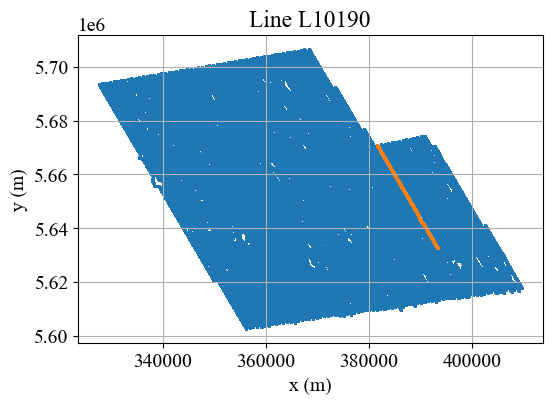

In [10]:
plt.scatter(xy[:, 0], xy[:, 1], s=1)
plt.scatter(xy[index, 0], xy[index, 1], s=1)
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title(f"Line {line_no[istart]}")

In [11]:
raws.fillna(1e-20)

,Line,bheight,TranPeak,x_wgs84,y_wgs84,flight,pwrline,zoff30[1],zoff30[2],zoff30[3],...,zoff30[20],zoff30[21],zoff30[22],zoff30[23],zoff30[24],zoff30[25],zoff30[26],zoff30[27],zoff30[28],zoff30[29]
0,L10040,51.911278,458.3756,402493.257158,5.641032e+06,503,-8,-1.425431e-09,-1.146254e-09,-9.643729e-10,...,-4.421049e-11,-3.535748e-11,-2.819742e-11,-2.205398e-11,-1.766893e-11,-1.247669e-11,-8.785390e-12,-7.733850e-12,-4.841026e-12,-1.900206e-12
1,L10040,51.951504,458.3796,402494.415637,5.641030e+06,503,-8,-1.422128e-09,-1.143961e-09,-9.625347e-10,...,-4.407762e-11,-3.520288e-11,-2.806906e-11,-2.192132e-11,-1.753630e-11,-1.227865e-11,-8.617931e-12,-7.688571e-12,-4.769593e-12,-1.846251e-12
2,L10040,51.990196,458.3752,402495.574117,5.641028e+06,503,-8,-1.418867e-09,-1.141693e-09,-9.607055e-10,...,-4.394562e-11,-3.507516e-11,-2.795435e-11,-2.177165e-11,-1.737787e-11,-1.208962e-11,-8.450681e-12,-7.656572e-12,-4.663391e-12,-1.805470e-12
3,L10040,52.028530,458.3842,402496.732597,5.641026e+06,503,-8,-1.415646e-09,-1.139441e-09,-9.588767e-10,...,-4.384081e-11,-3.497925e-11,-2.784985e-11,-2.162800e-11,-1.722122e-11,-1.193744e-11,-8.320386e-12,-7.639734e-12,-4.528806e-12,-1.775657e-12
4,L10040,52.065350,458.3826,402497.891079,5.641024e+06,503,-8,-1.412539e-09,-1.137258e-09,-9.570899e-10,...,-4.374807e-11,-3.491266e-11,-2.776143e-11,-2.149592e-11,-1.705858e-11,-1.180096e-11,-8.214438e-12,-7.616684e-12,-4.392304e-12,-1.752587e-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2468249,L10795,47.950359,460.7822,350092.607768,5.620167e+06,537,-14,-7.840540e-10,-6.313646e-10,-5.277656e-10,...,-1.627180e-11,-1.283453e-11,-1.178583e-11,-1.098103e-11,-9.639738e-12,-6.303172e-12,-5.539284e-12,-4.873522e-12,-3.023775e-12,-1.434382e-12
2468250,L10795,48.262875,460.7836,350094.300742,5.620164e+06,537,-14,-7.786760e-10,-6.269927e-10,-5.240232e-10,...,-1.615130e-11,-1.266985e-11,-1.156742e-11,-1.080611e-11,-9.521045e-12,-6.191078e-12,-5.297184e-12,-4.896154e-12,-3.036287e-12,-1.364667e-12
2468251,L10795,48.575470,460.7808,350095.995313,5.620162e+06,537,-14,-7.731655e-10,-6.224826e-10,-5.201460e-10,...,-1.597851e-11,-1.246160e-11,-1.133130e-11,-1.056570e-11,-9.328209e-12,-6.013345e-12,-5.037165e-12,-4.883507e-12,-3.022271e-12,-1.307476e-12
2468252,L10795,48.888226,460.7936,350097.689886,5.620159e+06,537,-14,-7.677030e-10,-6.180084e-10,-5.162822e-10,...,-1.579721e-11,-1.227103e-11,-1.110839e-11,-1.026474e-11,-9.100929e-12,-5.835848e-12,-4.760039e-12,-4.836396e-12,-2.999989e-12,-1.246418e-12


In [12]:
raws["x_wgs84"].values

array([402493.25715826, 402494.415637  , 402495.57411664, ...,
       350095.99531323, 350097.68988617, 350099.38446078])

In [13]:
dx = 50.
values = []
values_std = []
soundings = []

for i_line, line in enumerate(line_no[istart:iend]):
    df_line = raws[raws['Line']==line]

    # Calculate distance along the "Line"
    xy = df_line[["x_wgs84", "y_wgs84"]].to_numpy()
    distance = np.sqrt(((xy-xy[0,:])**2).sum(axis=1))
    max_distance = distance.max()

    # Determine the no. of soundings per bin.
    if max_distance % dx ==0:
        n_sounding = int(max_distance / dx)
    else:
        n_sounding = int(np.round(max_distance / dx) + 1)

    # Create bins and assign each sounding to a bin
    bins = np.arange(n_sounding) * dx
    df_line.insert(0, 'distance', distance)
    # Bin distances
    df_line['bin'] = pd.cut(df_line['distance'], bins=bins)
    # Compute statistics per bin
    binned = (
        df_line.groupby('bin', observed=False)
            [['distance'] + picker[1:]]
            .mean()
    )
    binned.insert(0, 'Line', line)
    binned_std = (
        df_line.groupby('bin', observed=False)
            [['bheight'] + dheader]
            .std()
    )
    values.append(binned.values)
    values_std.append(binned_std.values)
    soundings.append(n_sounding)

df_data_binned = pd.DataFrame(data=np.vstack(values), columns=['Line', 'distance'] + picker[1:])
df_data_std_binned = pd.DataFrame(data=np.vstack(values_std), columns=['bheight'] + dheader)

In [14]:
print(f"{soundings=}")

soundings=[800]

In [15]:
from sklearn.preprocessing import MinMaxScaler
from ipywidgets import widgets, interact

In [16]:
def plot_data(line, x):
    print(line)
    x_line = x[x["Line"]==line]

    fig, axs = plt.subplots(2,1, figsize=(20, 10), constrained_layout=True)
    ax0, ax1 = axs

    # (ax0) Plot the binned locations
    ax0.plot(x["x_wgs84"], x["y_wgs84"], '.')
    ax0.plot(x_line["x_wgs84"], x_line["y_wgs84"], '.')
    ax0.plot(x_line["x_wgs84"].values[0], x_line["y_wgs84"].values[0], 'o')
    ax0.set_aspect(0.2)

    # Normalize the altitude and power line monitor data.
    scaler = MinMaxScaler(feature_range=(x_line['bheight'].min(), x_line['bheight'].max())) # Min-Max scaler for pwrline to be in the same range as bheight
    plm_norm = scaler.fit_transform(x_line['pwrline'].values.reshape([-1,1]))

    # (ax1) Plot the normalized data
    ax2 = ax1.twinx()
    ax1.semilogy(x_line['x_wgs84'], np.abs(x_line[dheader]), color='k', lw=2)
    ax2.plot(x_line['x_wgs84'], plm_norm, '-', color='red', label='PLM', lw=1.5)
    ax2.plot(x_line['x_wgs84'], x_line['bheight'], '-', label='Flight height', lw=1.5, color='magenta')
    ax2.legend()

In [17]:
interact(plot_data, line=widgets.Select(options=line_no[istart:iend]), x=widgets.fixed(df_data_binned))

interactive(children=(Select(description='line', options=('L10190',), value='L10190'), Output()), _dom_classes…

<function __main__.plot_data(line, x)>

- standard deviation
$$
\sigma=\frac{1}{N}\sqrt{\sum_{i=1^N}{(x_i-\bar{x})^2}}
$$
- field normalized standard deviation (root-mean-squared relative error)
$$
\frac{\sigma}{d}=\frac{1}{N}\sqrt{\sum_{i=1^N}{\frac{(x_i-\bar{x})^2}{x_i^2}}}
$$

In [18]:
# Extract timeseries data
data_ = df_data_binned[dheader].values.astype(float)
# Extract field normalized standard deviation (root mean squared relative error)
data_rerr = (df_data_std_binned[dheader].values / np.abs(df_data_binned[dheader].values)).astype(float)

In [19]:
# Cut-off for bad data (relative error > 5%)
criteria:float = 0.05
channel_id = np.tile(np.arange(data_.shape[1]), (data_.shape[0], 1))
cut_off = (data_rerr>criteria) * (channel_id>=0)

In [20]:
data_[cut_off] = np.nan
data_rerr[cut_off] = np.nan

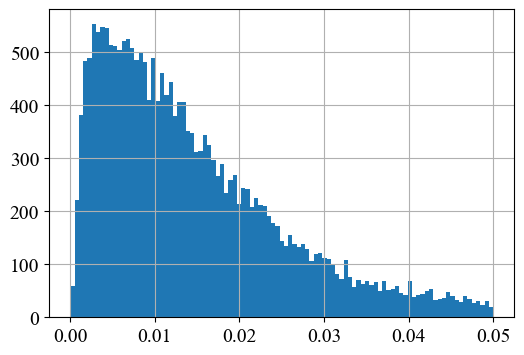

In [21]:
# Plot histogram of relative errors below the cut-off
hi = plt.hist(data_rerr[~cut_off], bins = np.linspace(0,criteria, 100))

In [22]:
def plot_soundinig(i_sounding):
    plt.errorbar(times, np.abs(data_[i_sounding,:])*1e9, yerr=data_rerr[i_sounding,:], fmt='-o')
    plt.yscale('log')
    plt.xscale('log')
    plt.xlabel("Time (s)")
    plt.ylabel("Field (nT/s)")

interact(plot_soundinig, i_sounding=widgets.IntSlider(min=0, max=data_.shape[0]-1, step=1, value=0))

interactive(children=(IntSlider(value=0, description='i_sounding', max=798), Output()), _dom_classes=('widget-…

<function __main__.plot_soundinig(i_sounding)>

In [23]:
df_data_binned

,Line,distance,bheight,TranPeak,x_wgs84,y_wgs84,flight,pwrline,zoff30[1],zoff30[2],...,zoff30[20],zoff30[21],zoff30[22],zoff30[23],zoff30[24],zoff30[25],zoff30[26],zoff30[27],zoff30[28],zoff30[29]
0,L10190,25.637542,37.451103,461.81474,381647.521707,5670786.228933,507.0,-11.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
1,L10190,75.299291,32.7394,461.81799,381661.645056,5670738.616658,507.0,-11.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
2,L10190,125.686219,30.285831,461.810829,381676.653568,5670690.511834,507.0,-11.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
3,L10190,175.769457,31.226034,461.812914,381692.498272,5670642.98395,507.0,-11.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
4,L10190,225.836818,33.561971,461.833848,381708.538731,5670595.541539,507.0,-11.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
794,L10190,39724.583827,28.397721,461.57397,393252.462383,5632821.348981,507.0,-11.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
795,L10190,39775.328078,30.053631,461.57479,393267.631888,5632772.923898,507.0,-11.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
796,L10190,39825.463838,31.567711,461.58201,393281.973837,5632724.882141,507.0,-11.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
797,L10190,39875.248964,33.744494,461.584324,393296.374501,5632677.224981,507.0,-11.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0


In [24]:
filtered_data = pd.DataFrame(
    data = np.hstack(
        (df_data_binned.iloc[:,:8].values, data_)
    ),
    columns=df_data_binned.columns.tolist()
)

In [25]:
interact(plot_data, line=widgets.Select(options=line_no[istart:iend]), x=widgets.fixed(filtered_data))

interactive(children=(Select(description='line', options=('L10190',), value='L10190'), Output()), _dom_classes…

<function __main__.plot_data(line, x)>

In [26]:
dobs = df_data_binned[dheader].values.flatten() # Binned Data
std = df_data_std_binned[dheader].values.flatten() # Standard deviation of Binned Data
dobs_std = abs(dobs) * criteria # 0.05 * Binned Data
dobs_std[std > dobs_std] = std[std > dobs_std] # Standard deviation having smaller than 0.05 * dobs will be replaced with 0.05 * dobs.
dobs_std[cut_off.flatten()] = np.inf
floors = 5*1e-9/df_data_binned["TranPeak"]/5

In [27]:
# Source loop geometry
source_location = np.array([
    df_data_binned["x_wgs84"].values,
    df_data_binned["y_wgs84"].values,
    df_data_binned["bheight"].values
    ])
source_orientation = "z"
source_current = 1
source_radius = 5

# Receiver geometry
receiver_location = np.array([
    df_data_binned["x_wgs84"].values,
    df_data_binned["y_wgs84"].values,
    df_data_binned["bheight"].values
    ])
receiver_orientation = "z"


In [28]:
# Define the source waveform. (unit step-off, rectangular, triangular, quarter-sine, custom)
# Triangular waveform. 
start_time = -1.74e-3
peak_time = -0.84e-3
off_time = 0.0
waveform = tdem.sources.TriangularWaveform(
    start_time,
    off_time,
    peak_time
)

In [29]:
# estimated host conductivity (S/m)
estimated_conductivity = 1e-2
# minimum diffusion distance
d_min = 1250 * np.sqrt(times.min() / estimated_conductivity)
print("MINIMUM DIFFUSION DISTANCE: {} m".format(d_min))
# maximum diffusion distance
d_max = 1250 * np.sqrt(times.max() / estimated_conductivity)
print("MAXIMUM DIFFUSION DISTANCE: {} m".format(d_max))

MINIMUM DIFFUSION DISTANCE: 143.99435752834205 m

MAXIMUM DIFFUSION DISTANCE: 688.6921482055681 m

In [30]:
depth_min = 5  # top layer thickness
depth_max = 300.0  # depth to lowest layer
geometric_factor = 1.15  # rate of thickness increase

In [31]:
# Increase subsequent layer thicknesses by the geometric factors until
# it reaches the maximum layer depth.
layer_thicknesses = [depth_min]
while np.sum(layer_thicknesses) < depth_max:
    layer_thicknesses.append(geometric_factor * layer_thicknesses[-1])

n_layers = len(layer_thicknesses) + 1  # Number of layers

In [32]:
l_bound = 1e-4
u_bound = 10
log_conductivity_map = maps.LogisticSigmoidMap(nP=n_layers, lower_bound=l_bound, upper_bound=u_bound) # nP is the number of layers

In [33]:
# Starting model is log-conductivity values (S/m)
starting_cond = 7e-2
# starting_conductivity_model = np.log(7e-2 * np.ones(n_layers))
starting_conductivity_model = np.log((starting_cond -l_bound)/(u_bound - starting_cond) * np.ones(n_layers))
# Reference model is also log-resistivity values (S/m)
reference_conductivity_model = starting_conductivity_model.copy()
# reference_conductivity_model = np.log(1e-2 * np.ones(n_layers))

In [34]:
# Define 1D cell widths
h = np.r_[layer_thicknesses, layer_thicknesses[-1]]
h = np.flipud(h)

# Create regularization mesh
regularization_mesh = TensorMesh([h], "N")
print(regularization_mesh)

TensorMesh: 18 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     18       -372.16         -0.00      5.00     46.79    1.15

In [35]:
chi_list = []
pred_list = []
recovered_list = []
for isrc in range(source_location.shape[1]):
    rx = tdem.receivers.PointMagneticFluxTimeDerivative(
        receiver_location[:,isrc].astype(float), times, orientation=receiver_orientation
        ) 
    src = tdem.sources.CircularLoop(
        receiver_list=rx,
        location=source_location[:, isrc].astype(float),
        orientation=source_orientation,
        waveform=waveform,
        current=source_current,
        radius=source_radius,
    )
    _dobs = dobs[(30-istart_channel)*isrc:(30-istart_channel)*(isrc+1)]
    uncertainties = criteria * np.abs(_dobs) + floors[isrc]
    survey = tdem.Survey(src)
    data_object = data.Data(survey, dobs=_dobs.astype(float), standard_deviation=uncertainties.astype(float))
    # source_list.append(src)

    simulation_L2 = tdem.Simulation1DLayered(
        survey=survey, thicknesses=layer_thicknesses, sigmaMap=log_conductivity_map
    )
    dmis_L2 = data_misfit.L2DataMisfit(simulation=simulation_L2, data=data_object)
    reg_L2 = regularization.WeightedLeastSquares(
        regularization_mesh,
        alpha_s=1e-10,
        # alpha_x=0.0, # weighting for the first derivative term
        length_scale_x=10.0,
        reference_model=reference_conductivity_model,# Log resistivity
        reference_model_in_smooth=False,
    )
    opt_L2 = optimization.InexactGaussNewton(
        maxIter=20, maxIterLS=20, cg_maxiter=50, cg_rtol=1e-3
    )
    inv_prob_L2 = inverse_problem.BaseInvProblem(dmis_L2, reg_L2, opt_L2)

    # Inversion Directives
    update_jacobi = directives.UpdatePreconditioner(update_every_iteration=True)
    # Initial beta
    starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=5)
    # Beta schedule: Decrease beta by a factor of 2 every 3 iterations
    beta_schedule = directives.BetaSchedule(coolingFactor=2.0, coolingRate=3)
    target_misfit = directives.TargetMisfit(chifact=1.0)

    directives_list_L2 = [update_jacobi, starting_beta, beta_schedule, target_misfit]
    # Here we combine the inverse problem and the set of directives
    inv_L2 = inversion.BaseInversion(inv_prob_L2, directives_list_L2)
    # Run the inversion
    recovered_model_L2 = inv_L2.run(starting_conductivity_model)
    final_misfit = dmis_L2(recovered_model_L2)
    chi_squared = final_misfit / times.size
    print(f"{chi_squared=:.2f}")
    chi_list.append(chi_squared)
    pred_list.append(simulation_L2.dpred(recovered_model_L2))
    recovered_conductivities = log_conductivity_map * recovered_model_L2
    recovered_list.append(recovered_conductivities)

    # if isrc ==21:
    #     break
    

INFO: Directive TargetMisfit: Target data misfit is 29.0



Running inversion with SimPEG v0.25.2
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  1.12e+00  1.43e+03  2.23e-28  1.43e+03                                 
   1  1.12e+00  1.40e+02  9.36e+00  1.51e+02    1.24e+03      1              
   2  1.12e+00  3.12e+01  2.47e+01  5.90e+01    5.55e+02      0              
   3  1.12e+00  2.59e+01  2.27e+01  5.13e+01    2.33e+02      0              
------------------------- STOP! -------------------------
1 : |fc-fOld| = 7.6814e+00 <= tolF*(1+|f0|) = 1.4322e+02
1 : |xc-x_last| = 1.2906e-01 <= tolX*(1+|x0|) = 2.2028e+00
0 : |proj(x-g)-x|    = 2.3319e+02 <= tolG          = 1.0000e-01
0 : |proj(x-g)-x|    = 2.3319e+02 <= 1e3*eps       = 1.0000e-02
0 : maxIter   =      20    <= iter          =      3
------------------------- DONE! -------------------------


chi_squared=0.89

INFO: Directive TargetMisfit: Target data misfit is 29.0



Running inversion with SimPEG v0.25.2
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  1.20e+00  1.35e+03  2.23e-28  1.35e+03                                 
   1  1.20e+00  1.37e+02  7.46e+00  1.46e+02    1.30e+03      1              
   2  1.20e+00  2.53e+01  1.94e+01  4.86e+01    6.10e+02      0              
------------------------- STOP! -------------------------
1 : |fc-fOld| = 9.7775e+01 <= tolF*(1+|f0|) = 1.3540e+02
1 : |xc-x_last| = 9.3981e-01 <= tolX*(1+|x0|) = 2.2028e+00
0 : |proj(x-g)-x|    = 6.0985e+02 <= tolG          = 1.0000e-01
0 : |proj(x-g)-x|    = 6.0985e+02 <= 1e3*eps       = 1.0000e-02
0 : maxIter   =      20    <= iter          =      2
------------------------- DONE! -------------------------


...

chi_squared=1.39


Running inversion with SimPEG v0.25.2


INFO: Directive TargetMisfit: Target data misfit is 29.0


============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  1.19e+01  6.04e+03  2.23e-28  6.04e+03                                 
   1  1.19e+01  4.74e+02  2.12e+00  4.99e+02    8.49e+03      0              
   2  1.19e+01  7.34e+01  1.77e+00  9.45e+01    1.28e+03      0              
   3  1.19e+01  7.46e+01  1.23e+00  8.93e+01    1.08e+02      0              
   4  5.96e+00  6.32e+01  2.62e+00  7.88e+01    3.98e+01      0              
   5  5.96e+00  6.34e+01  2.59e+00  7.88e+01    3.78e+00      0              
   6  5.96e+00  6.33e+01  2.59e+00  7.88e+01    1.87e-01      0              
   7  2.98e+00  5.50e+01  4.55e+00  6.86e+01    3.18e+01      0              
   8  2.98e+00  5.51e+01  4.52e+00  6.86e+01    2.92e+00      0              
   9  2.98e+00  5.51e+01  4.52e+00  6.86e+01    1.50e-01      0

chi_squared=1.67

In [54]:
def plot_results(i_sounding):
    fig,axes = plt.subplot_mosaic([["1","2"]], figsize = (12,5))
    axes["1"].loglog(times, np.abs(pred_list[i_sounding]),c='red')
    axes["1"].loglog(times, np.abs(dobs[(30-istart_channel)*i_sounding:(30-istart_channel)*(i_sounding+1)]),'kX', ms=5)
    axes["1"].axhline(floors[i_sounding], c='gray', ls='--')
    axes["1"].set_xlabel(r"Time (channels)")
    axes["1"].set_ylabel(r"Hz (T/sec)")
    axes["1"].legend(["Predictio", "Observation", "Floors"])
    axes["1"].set_xlim([1e-4,4e-3])
    axes["1"].set_ylim([1e-12, 1e-8])
    axes["1"].set_title("$\chi$:" + f"{chi_list[i_sounding]:.2f}")
    plot_1d_layer_model(
        layer_thicknesses, 1/recovered_list[i_sounding], ax=axes["2"], color="b", lw=3,
    )
    axes["2"].set_xlabel(r"Resistivity ($\Omega m$)")
    axes["2"].legend(["L2-Model", "Bedrock (Top)"])
    axes["2"].set_xlim([1,100])
    axes["2"].set_xticks([1,10,20,50,100])

interact(plot_results, i_sounding=widgets.IntSlider(min=0, max=len(pred_list)-1, step=1, value=0))

<>:11: SyntaxWarning: invalid escape sequence '\c'
<>:11: SyntaxWarning: invalid escape sequence '\c'
/var/folders/2c/w5d04hwn6k56y8m_fmjdt1v40000gn/T/ipykernel_6251/2080239222.py:11: SyntaxWarning: invalid escape sequence '\c'
  axes["1"].set_title("$\chi$:" + f"{chi_list[i_sounding]:.2f}")


interactive(children=(IntSlider(value=0, description='i_sounding', max=798), Output()), _dom_classes=('widget-…

<function __main__.plot_results(i_sounding)>

<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\c'
/var/folders/2c/w5d04hwn6k56y8m_fmjdt1v40000gn/T/ipykernel_6251/4009388665.py:2: SyntaxWarning: invalid escape sequence '\c'
  plt.title("$\chi$ distirbution")


Text(0.5, 1.0, '$\\chi$ distirbution')

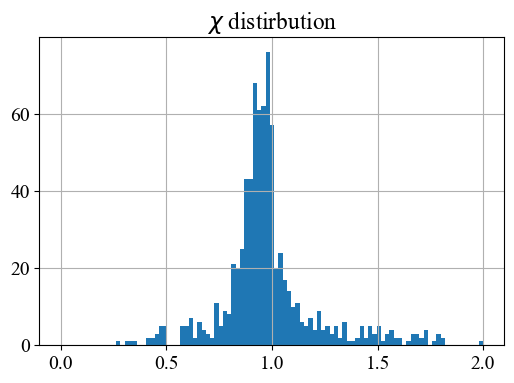

In [55]:
out = plt.hist(chi_list, bins=np.linspace(0,2,100))
plt.title("$\chi$ distirbution")